In [80]:
# Import the required libraries 
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split,cross_val_score,RandomizedSearchCV
from sklearn.metrics import r2_score,mean_absolute_error,root_mean_squared_error

In [81]:
FILE_PATH = Path.cwd().parent / "datasets" / "housing.csv" # Dynamic path handling cause of the dataset stored in folder of same tree level

In [82]:
df = pd.read_csv(FILE_PATH) 

In [83]:
df.shape # A lot of rows

(20640, 10)

In [84]:
df.head() # Seems like most of the columns are numeric except one

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [85]:
# For this problem we will try to predict the median house_value here and it will act as y.

In [86]:
df.info() # The total bedrooms do have some null values , wee need to tackle them

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [87]:
df.isna().sum() #   A total of 207 empty values 

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [88]:
# This is the percentage of null values compared to the no of rows
# Actually at this point we can drop these but we will try to fins whether there are any patterns for null values
100 - df.shape[0]/df.isna().sum()['total_bedrooms']

np.float64(0.28985507246376585)

<Axes: >

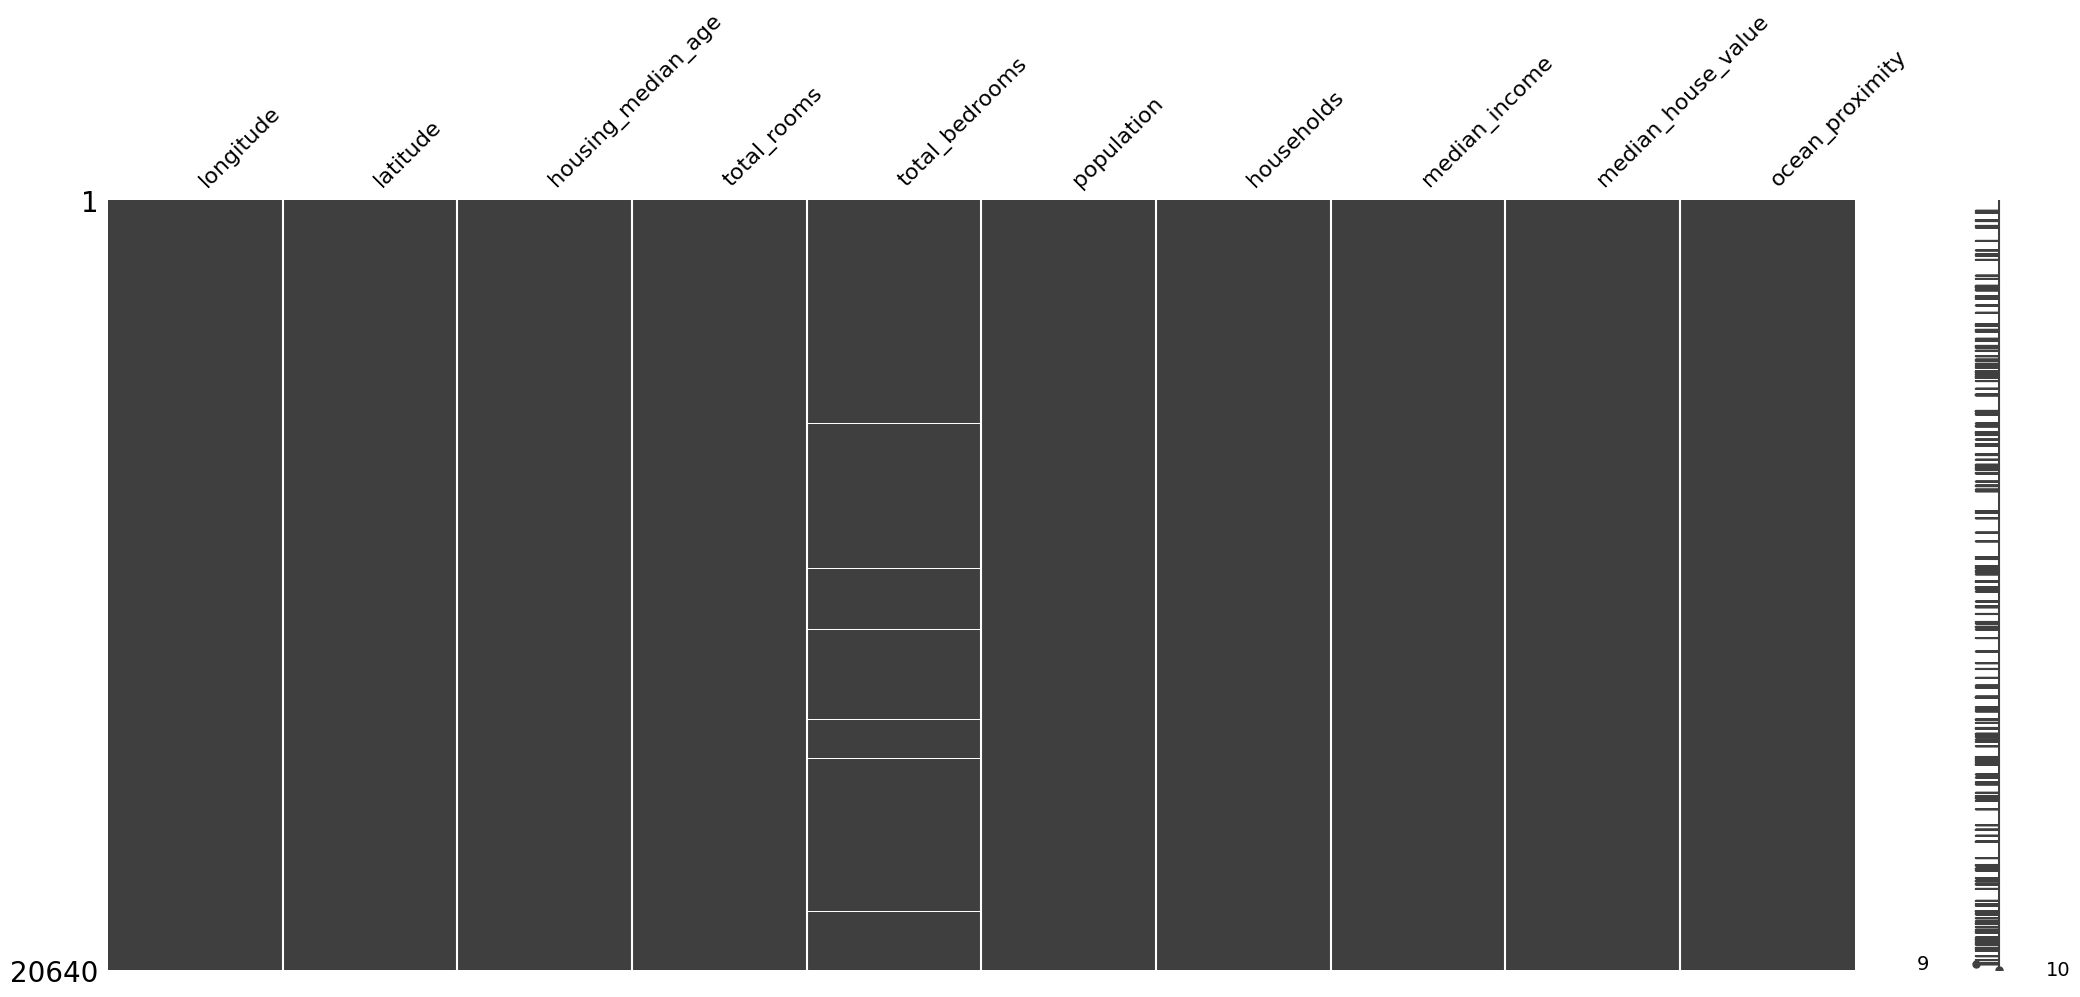

In [89]:
import missingno as msno
msno.matrix(df) # Looks like it is MCAR

In [90]:
df[df['total_bedrooms'].isna()].head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
290,-122.16,37.77,47.0,1256.0,NaN,570.0,218.0,4.3750,161900.0,NEAR BAY
341,-122.17,37.75,38.0,992.0,NaN,732.0,259.0,1.6196,85100.0,NEAR BAY
538,-122.28,37.78,29.0,5154.0,NaN,3741.0,1273.0,2.5762,173400.0,NEAR BAY
563,-122.24,37.75,45.0,891.0,NaN,384.0,146.0,4.9489,247100.0,NEAR BAY
696,-122.10,37.69,41.0,746.0,NaN,387.0,161.0,3.9063,178400.0,NEAR BAY
738,-122.14,37.67,37.0,3342.0,NaN,1635.0,557.0,4.7933,186900.0,NEAR BAY
1097,-121.77,39.66,20.0,3759.0,NaN,1705.0,600.0,4.7120,158600.0,INLAND
1350,-121.95,38.03,5.0,5526.0,NaN,3207.0,1012.0,4.0767,143100.0,INLAND
1456,-121.98,37.96,22.0,2987.0,NaN,1420.0,540.0,3.6500,204100.0,INLAND
1493,-122.01,37.94,23.0,3741.0,NaN,1339.0,499.0,6.7061,322300.0,NEAR BAY


In [91]:
# I am currently unable to find any patterns , so dropping for now .

In [92]:
df = df.dropna()

In [93]:
df.shape

(20433, 10)

In [94]:
# We have to check the conditon of feature independence but we cannot at this moment because of the categorical column at the end

In [95]:
df['ocean_proximity'].nunique() # We have 5 columns so we are in the range of making OHE columns 
# Let's check the counts for each category

5

In [96]:
df['ocean_proximity'].value_counts() # We clearly see that islands are only 5 to begin with , we must use pd.dummies cautiously

ocean_proximity
<1H OCEAN     9034
INLAND        6496
NEAR OCEAN    2628
NEAR BAY      2270
ISLAND           5
Name: count, dtype: int64

In [97]:
df = pd.get_dummies(df,columns=['ocean_proximity'],dtype="int",drop_first=False)

In [98]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,0,1,0


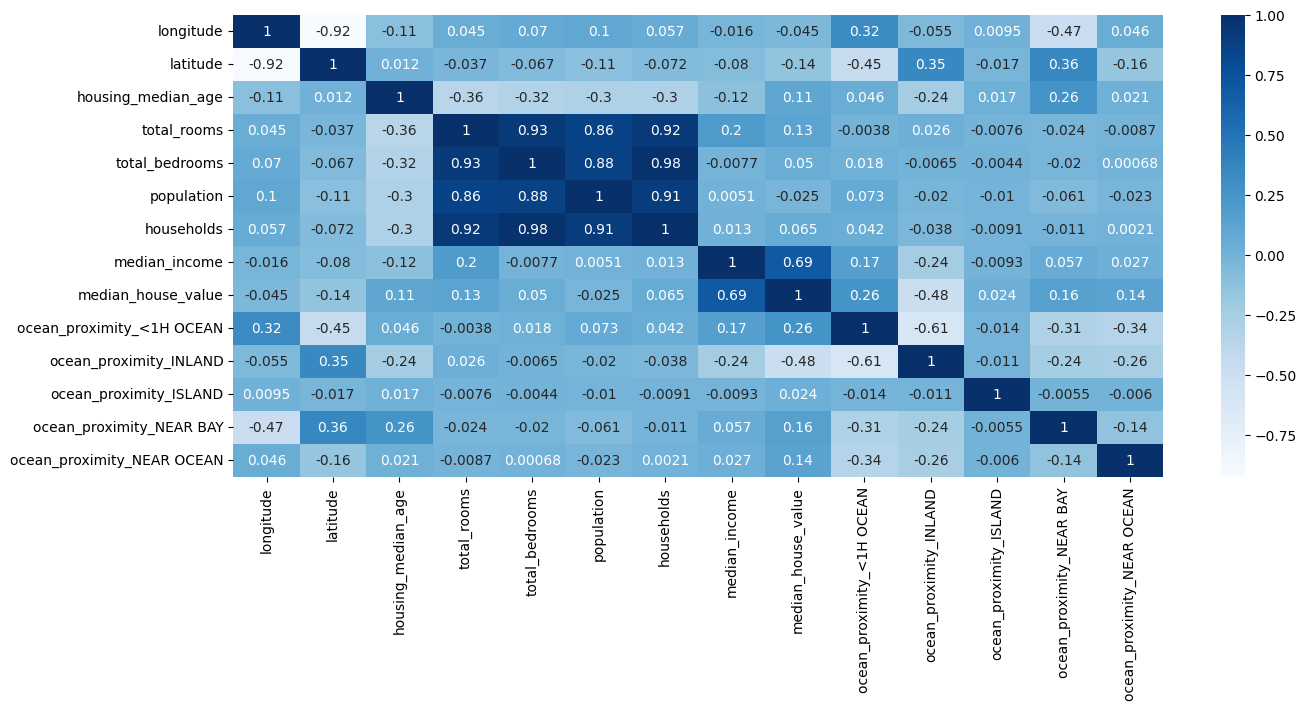

In [123]:
# Now is the perfect time to peek into the corr heatmap
plt.figure(figsize=(15,6))
sns.heatmap(df.corr(),cmap="Blues",annot=True)
plt.show()

In [124]:
# There are a lot of correlated columns as expected
# At this we have some options :
# Use tree algorithm instead of linear model which handles multicollinearity
# Combine commone features into one
# USE the column total_rooms only and drop other 
# Calculate the VIF value for cols
# PCA

In [125]:
# I will go with dropping the cluster and only keeping total_rooms as I think it already catches the info which is being dropped
# Also if we look closely there is literally only a single column that correlated to median_house_income
# I think this data is not enough for building models to be honest